Using this data, the goal is to identify which features or vehicle brands are linked to the lowest churn rates, and which actions are associated with the best retention rates.


In [1]:
import pandas as pd
import os
from pathlib import Path
from matplotlib.axes import Axes

Change working directory to root folder if needed below:

In [ ]:
# os.chdir(Path.cwd().parent)

In [3]:
os.getcwd()

'c:\\Users\\Tomas\\Desktop\\Thesis Stuff\\Survival_Analysis_Thesis\\Coding'

In [ ]:
from src.constants import paths_to_files_and_folders as const
from src.data_cleaning import DataCleaner
import src.constants.thesis_style as style
# from src.plotting import PlottingData

_Step 1_
Rows before merging: 567953
Rows after merging: 567953

Removing user_ids that aren't present in vehicle dataset
Rows before user filtering: 567953
Rows after user filtering: 567352

Removing duplicate rows
Rows before deduplication: 567352
Rows after deduplication: 560583

_Step 2_
Transforming missing vehicle_end_year values to current year
Current year used: 2026
Missing vehicle_end_year values filled: 41626

_Step 3_
Number of one-day-users: 105
Rows before one-day-user filtering: 560583
Rows after one-day-user filtering: 559649
Rows removed: 934

_Step 4_
Rows before user type filtering: 559649


| Variable | Short explanation |
|---|---|
| `coding` | Manual coding/adaptation of vehicle control units. |
| `scan` | Diagnostic scan for faults/DTCs across vehicle systems. |
| `clear` | Clearing/deleting detected fault codes. |
| `oca` | One-Click App: prebuilt coding/action shortcut. |
| `history_screen` | Viewing previous scans, actions, or vehicle history. |
| `live_data` | Real-time sensor/control-unit data. |
| `vehicle_lookup` | Looking up vehicle info/details from VIN or garage. |
| `native_live_data` | Brand/manufacturer-specific live data, likely richer than generic OBD2. |
| `mileage_rollback` | Mileage fraud / rollback detection check. |
| `cba_checklist` | Car Buying Assistant / inspection checklist feature. |
| `trip_tracker` | Tracking trips or driving sessions. |
| `vehicle_report` | Generated vehicle health/diagnostic report. |
| `engine_readiness` | Emissions/readiness monitor status check. |
| `car_alert` | Alerts/notifications about vehicle issues or status. |
| `battery_check` | Battery or hybrid battery condition check. |
| `maintenance_reminder` | Reminder for service, inspection, or maintenance tasks. |

In [ ]:
activity_df_1000 = pd.read_csv(const.PATH_TO_RAW_ACTIVITY_DATA_1000)
vehicle_df_1000 = pd.read_csv(const.PATH_TO_RAW_VEHICLE_DATA_1000)
activity_df_1000.describe()


,user_id,vehicle_id,activity_date,app,activity_type
count,567953,554836,567953,567953,567953
unique,2787,26863,561148,2,16
top,e09387158db6388ce102a8a8cbf9d625146aa180a1b038...,fe671deb46ae9b6e7f9306e9d1bf33dc680b4c4475093b...,2025-03-19T15:48:06.918Z,VAG,scan
freq,17537,3073,2,415350,133244


In [ ]:
activity_df_1000[activity_df_1000["vehicle_id"].isna()].sort_values(by=["user_id","activity_date"])

vehicle_df_1000.groupby(by="user_id")["vehicle_id"].sum()
vehicle_df_1000["user_id"].nunique()

2767

In [ ]:
data_cleaner_1000 = DataCleaner(activity_df_1000,vehicle_df_1000)

df_1000_personal = data_cleaner_1000.get_clean_data(
                            merge_data_frames=True,
                            # filter_inactivity=True,
                            filter_nan_cols=None,
                            filter_by_user_type=True,
                            return_personal_use_users=True, # Personal
                            filter_one_day_users=True, 
                            # filter_by_set_cutoff_date=True,
                            transform_vehicle_end_year_to_present=True,
                            # filter_nan_vehicle_metadata = True,
                            # threshold_value = 180,
                            inverse_hhi_threshold = 6,
                            car_share_threshold_abs = 4,
                            car_share_threshold_fraction = 0.8)

df_1000_professional = data_cleaner_1000.get_clean_data(
                                                    merge_data_frames=True,
                                                    filter_nan_cols=None,
                                                    filter_inactivity=False,
                                                    filter_by_user_type=True,
                                                    return_personal_use_users=False, # Professional
                                                    filter_one_day_users=True,
                                                    filter_by_set_cutoff_date=False,
                                                    transform_vehicle_end_year_to_present=True,
                                                    filter_nan_vehicle_metadata=True)

df_1000_personal["activity_date"] = pd.to_datetime(df_1000_personal["activity_date"])
df_1000_professional["activity_date"] = pd.to_datetime(df_1000_professional["activity_date"])


merged_raw_1000 = data_cleaner_1000.get_clean_data(
    merge_data_frames=True,
    filter_nan_cols=["vehicle_id"]
)

# data_plotter = PlottingData()

_Step 1_
Rows before merging: 567953
Rows after merging: 567953

Removing user_ids that aren't present in vehicle dataset
Rows before user filtering: 567953
Rows after user filtering: 567352

Removing duplicate rows
Rows before deduplication: 567352
Rows after deduplication: 560583

_Step 2_
Transforming missing vehicle_end_year values to current year
Current year used: 2026
Missing vehicle_end_year values filled: 41626

_Step 3_
Number of one-day-users: 105
Rows before one-day-user filtering: 560583
Rows after one-day-user filtering: 559649
Rows removed: 934

_Step 4_
Rows before user type filtering: 559649
Filtering by personal users!
Rows after user type filtering: 171165


Cleaning complete
Final rows: 171165
Final unique users: 2345

_Step 1_
Rows before merging: 567953
Rows after merging: 567953

Removing user_ids that aren't present in vehicle dataset
Rows before user filtering: 567953
Rows after user filtering: 567352

Removing duplicate rows
Rows before deduplication: 567352
R

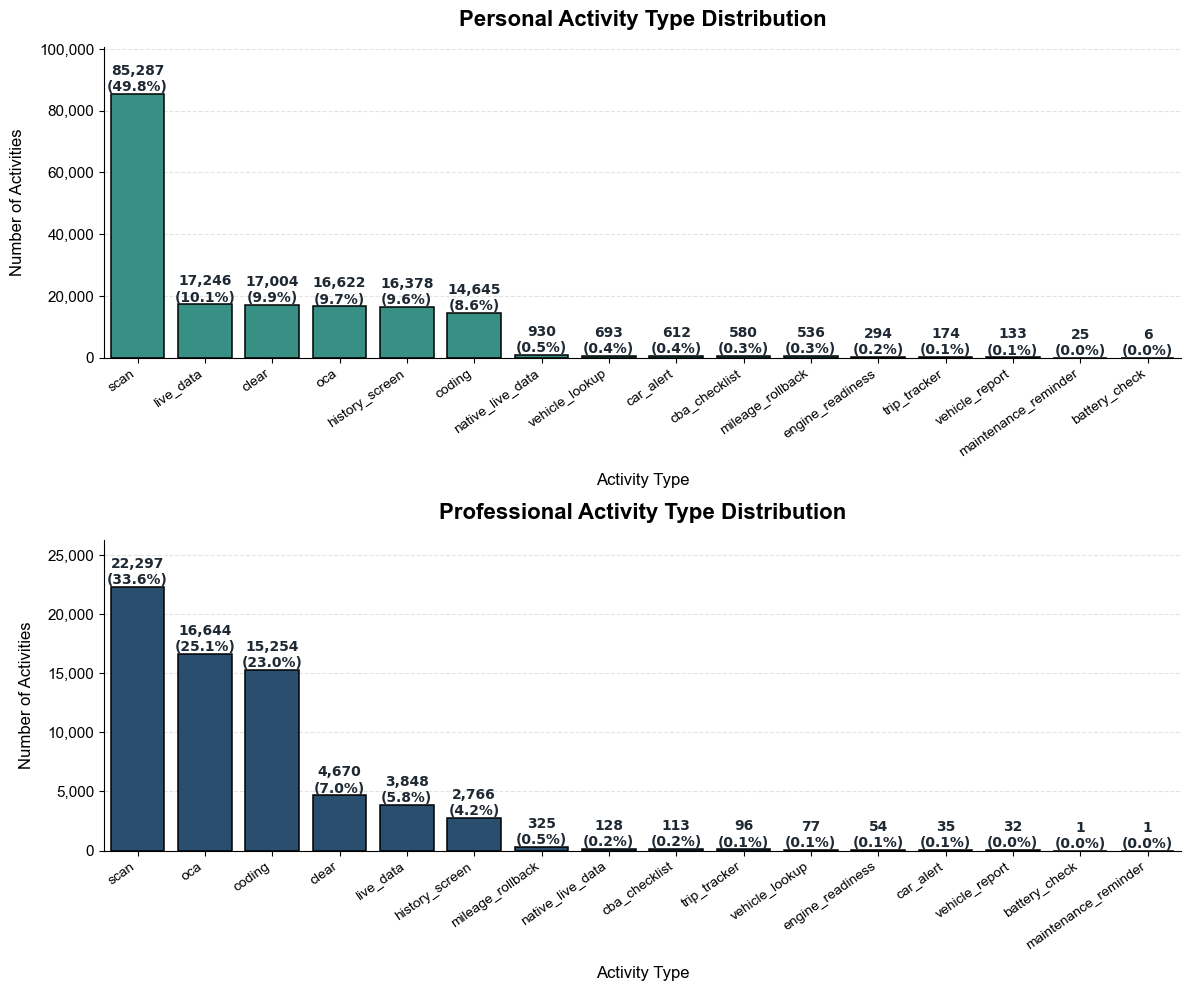

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plot
from matplotlib.ticker import StrMethodFormatter



def plot_activity_distribution(ax, df, title, color):
    activity_counts = (
        df["activity_type"]
        .value_counts()
        .sort_values(ascending=False)
    )

    total_activities = activity_counts.sum()
    sns.set_theme(**style.SEABORN_THEME)
    sns.barplot(
        x=activity_counts.index,
        y=activity_counts.values,
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=1.1
    )

    labels = [
        f"{count:,}\n({count / total_activities * 100:.1f}%)"
        for count in activity_counts.values
    ]

    for bar, label in zip(ax.patches, labels):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(title, fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Activity Type", fontsize=12, labelpad=10)
    ax.set_ylabel("Number of Activities", fontsize=12, labelpad=10)

    ax.tick_params(axis="x", rotation=35, labelsize=10)
    ax.tick_params(axis="y", labelsize=11)

    for label in ax.get_xticklabels():
        label.set_ha("right")

    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(0, activity_counts.max() * 1.18)


fig, axes = plot.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 10),
    sharey=False
)

plot_activity_distribution(
    ax=axes[0],
    df=df_1000_personal,
    title="Personal Activity Type Distribution",
    color=style.PALETTE["Personal"]
)

plot_activity_distribution(
    ax=axes[1],
    df=df_1000_professional,
    title="Professional Activity Type Distribution",
    color=style.PALETTE["Professional"]
)

plot.tight_layout()
plot.show()

In [ ]:


percentage_car_share_general = (
    merged_raw_1000
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_general = percentage_car_share_general.pow(2).groupby(level=0).sum()
n_general = percentage_car_share_general.groupby(level=0).size()
effective_hhi_general = 1 / hhi_general

effective_hhi_general.describe(percentiles=[0.25,0.50,0.75,0.8,0.90,0.95,0.99])

count    2754.000000
mean        3.892197
std        19.243545
min         1.000000
25%         1.068192
50%         1.785864
75%         2.910835
80%         3.398016
90%         5.698974
95%         9.433070
99%        32.518588
max       842.074508
Name: proportion, dtype: float64

In [ ]:
personal_user_count = df_1000_personal["user_id"].nunique()
professional_user_count = df_1000_professional["user_id"].nunique()

print(
    f"Personal users: {personal_user_count}",
    f"Professional users: {professional_user_count}",sep="\n"
)


Personal users: 2345
Professional users: 305


2345 305


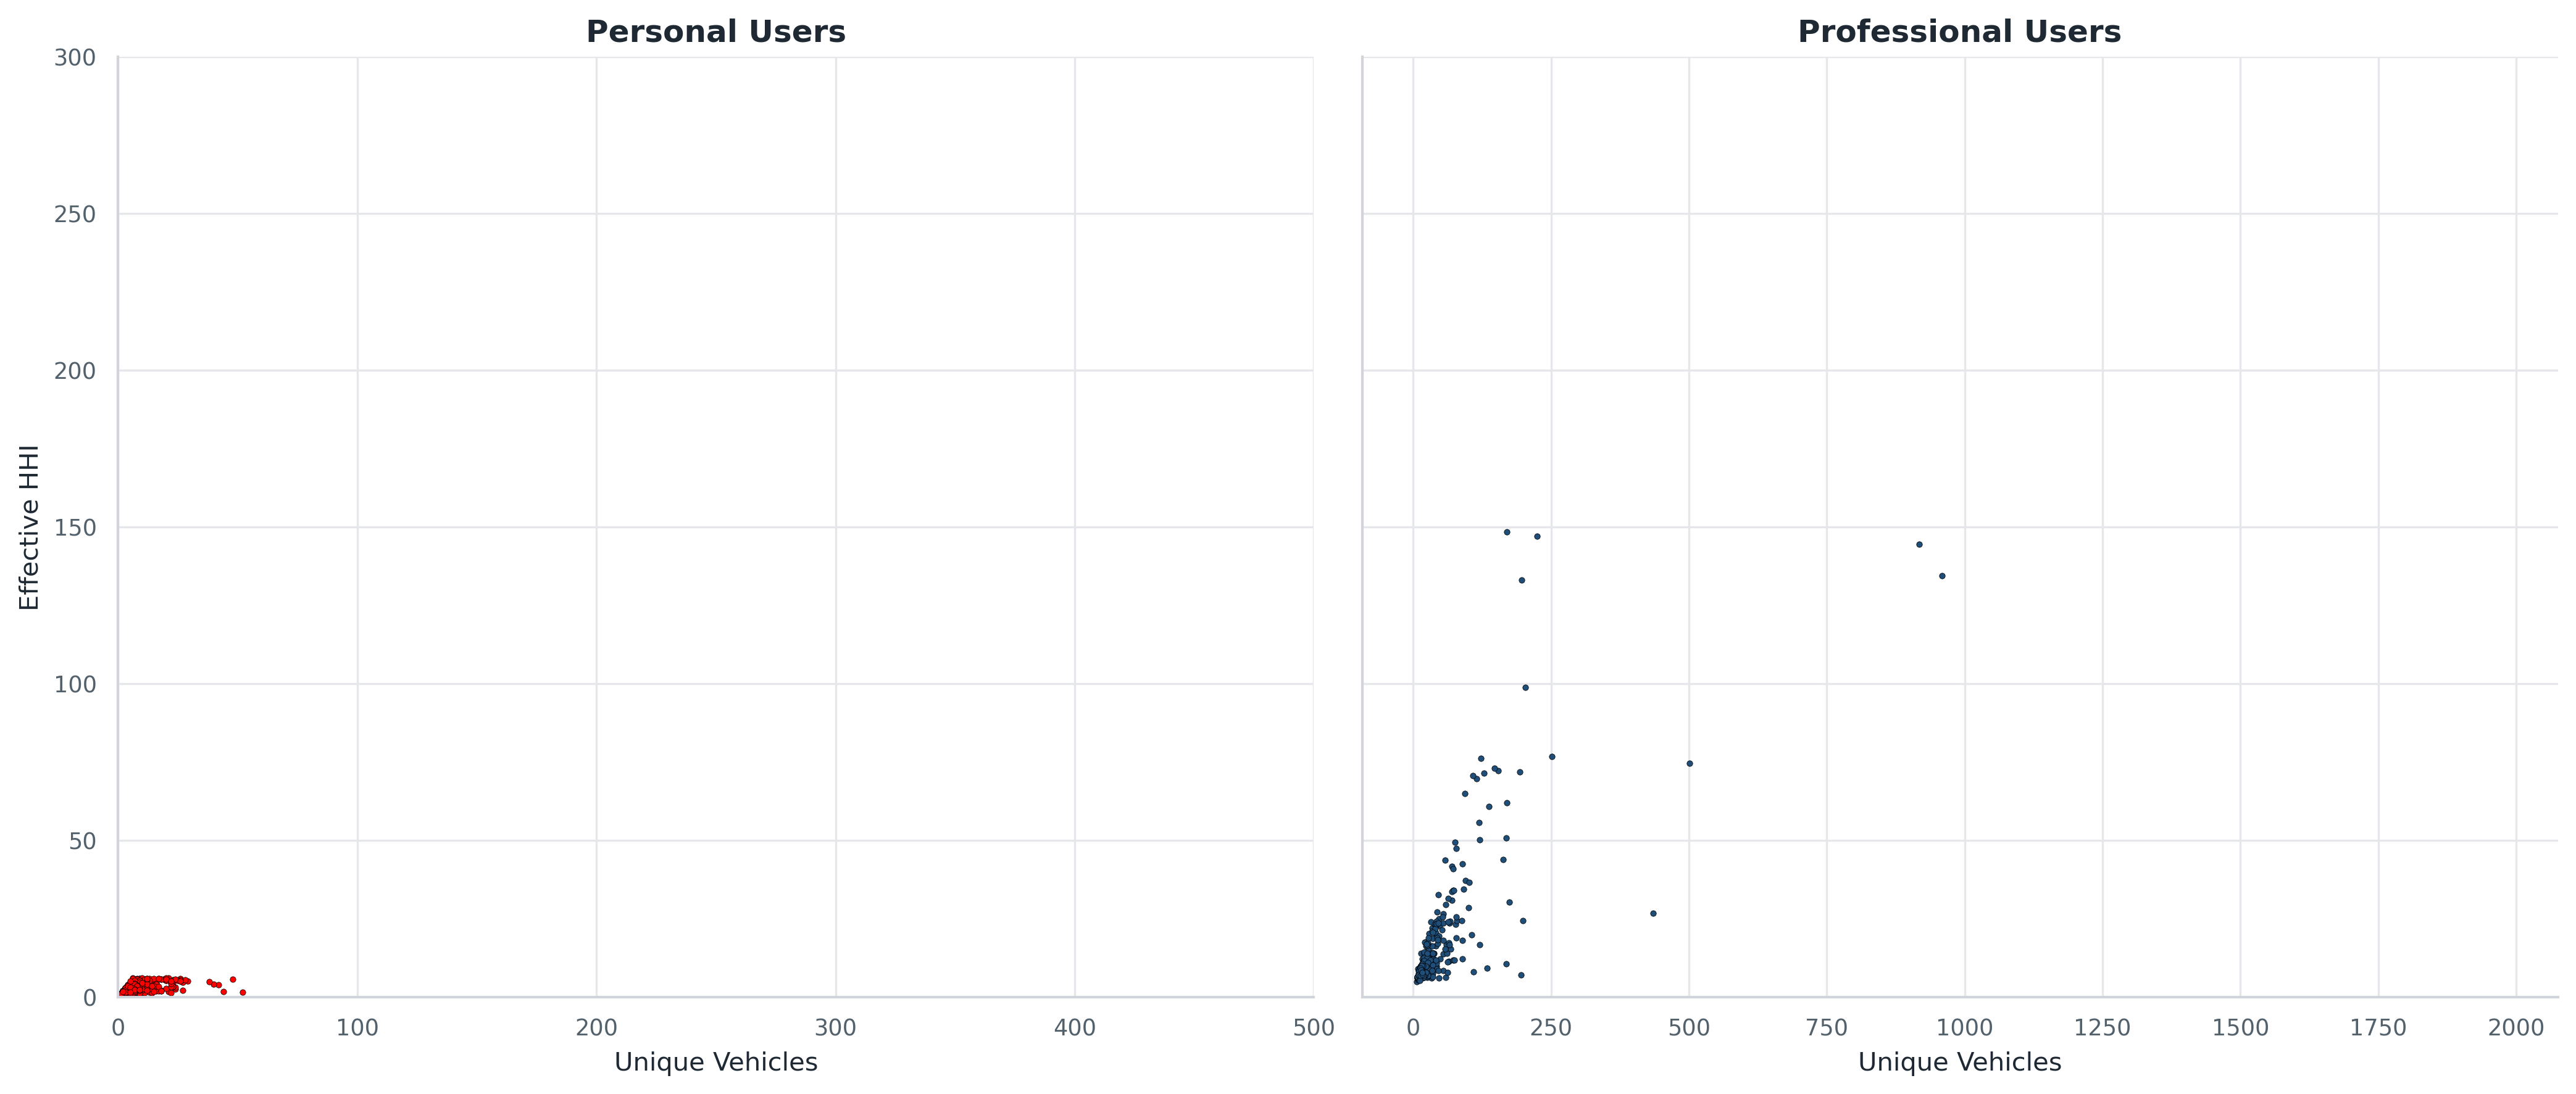

In [ ]:
fig1, ax1 = plot.subplots(nrows=1, ncols=2, sharey=True)

# Personal
percentage_car_share_personal = (
    df_1000_personal
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_personal = percentage_car_share_personal.pow(2).groupby(level=0).sum()
n_personal = percentage_car_share_personal.groupby(level=0).size()
effective_hhi_personal = 1 / hhi_personal

sns.scatterplot(x=n_personal, y=effective_hhi_personal,
                ax=ax1[0], s=5, color="red", edgecolor="black")
ax1[0].set_ylabel("Effective HHI")
ax1[0].set_xlabel("Unique Vehicles")
ax1[0].set_title("Personal Users")
ax1[0].set_xlim(0, 500)
ax1[0].set_ylim(0,300)
# Professional
percentage_car_share_professional = (
    df_1000_professional
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_professional = percentage_car_share_professional.pow(2).groupby(level=0).sum()
n_professional = percentage_car_share_professional.groupby(level=0).size()
effective_hhi_professional = 1 / hhi_professional

sns.set_theme(**style.SEABORN_THEME)
sns.scatterplot(x=n_professional, y=effective_hhi_professional,
                ax=ax1[1], s=5, color=style.PALETTE["Professional"], edgecolor="black",
                )
ax1[1].set_ylabel("Effective HHI")
ax1[1].set_xlabel("Unique Vehicles")
ax1[1].set_title("Professional Users")


fig1.set_tight_layout(tight=True)
fig1.set_size_inches((14, 6))



print(len(hhi_personal),len(hhi_professional))



2345 305


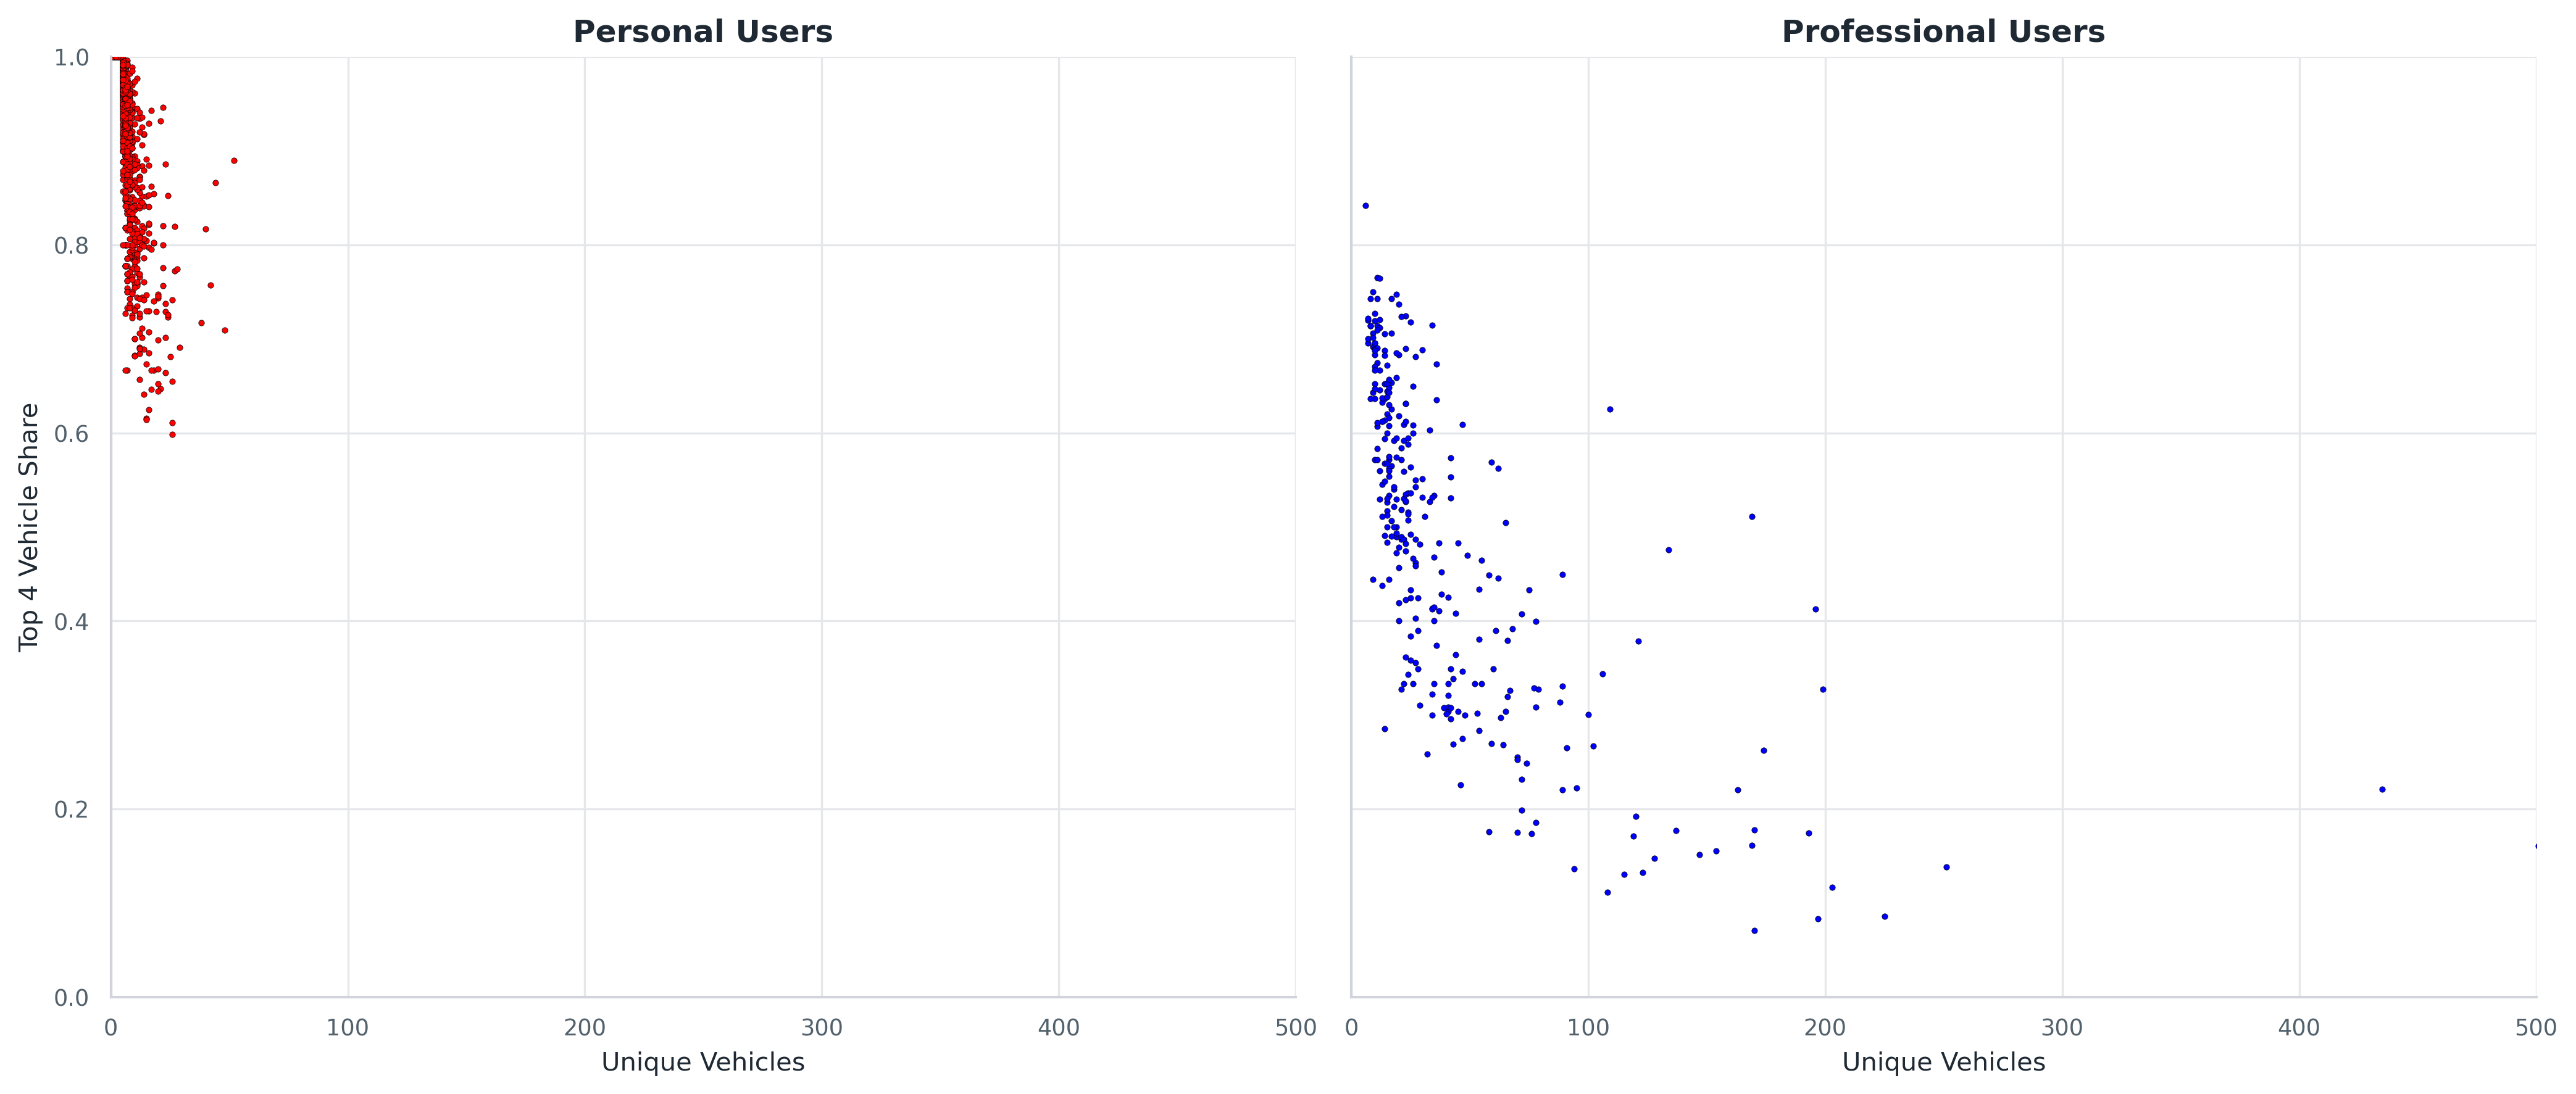

In [ ]:
fig1, ax1 = plot.subplots(nrows=1, ncols=2, sharey=True)

# Personal
percentage_car_share_personal = (
    df_1000_personal
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

top4_share_personal = (
    percentage_car_share_personal
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

n_personal = percentage_car_share_personal.groupby(level=0).size()

sns.scatterplot(x=n_personal, y=top4_share_personal,
                ax=ax1[0], s=5, color="red", edgecolor="black")


ax1[0].set_ylabel("Top 4 Vehicle Share")
ax1[0].set_xlabel("Unique Vehicles")
ax1[0].set_title("Personal Users")
ax1[0].set_xlim(0, 500)
ax1[0].set_ylim(0, 1)

# Professional
percentage_car_share_professional = (
    df_1000_professional
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

top4_share_professional = (
    percentage_car_share_professional
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

n_professional = percentage_car_share_professional.groupby(level=0).size()

sns.scatterplot(x=n_professional, y=top4_share_professional,
                ax=ax1[1], s=5, color="blue", edgecolor="black")
ax1[1].set_ylabel("Top 4 Vehicle Share")
ax1[1].set_xlabel("Unique Vehicles")
ax1[1].set_title("Professional Users")
ax1[1].set_xlim(0, 500)

fig1.set_tight_layout(tight=True)
fig1.set_size_inches((14, 6))

print(len(top4_share_personal), len(top4_share_professional))

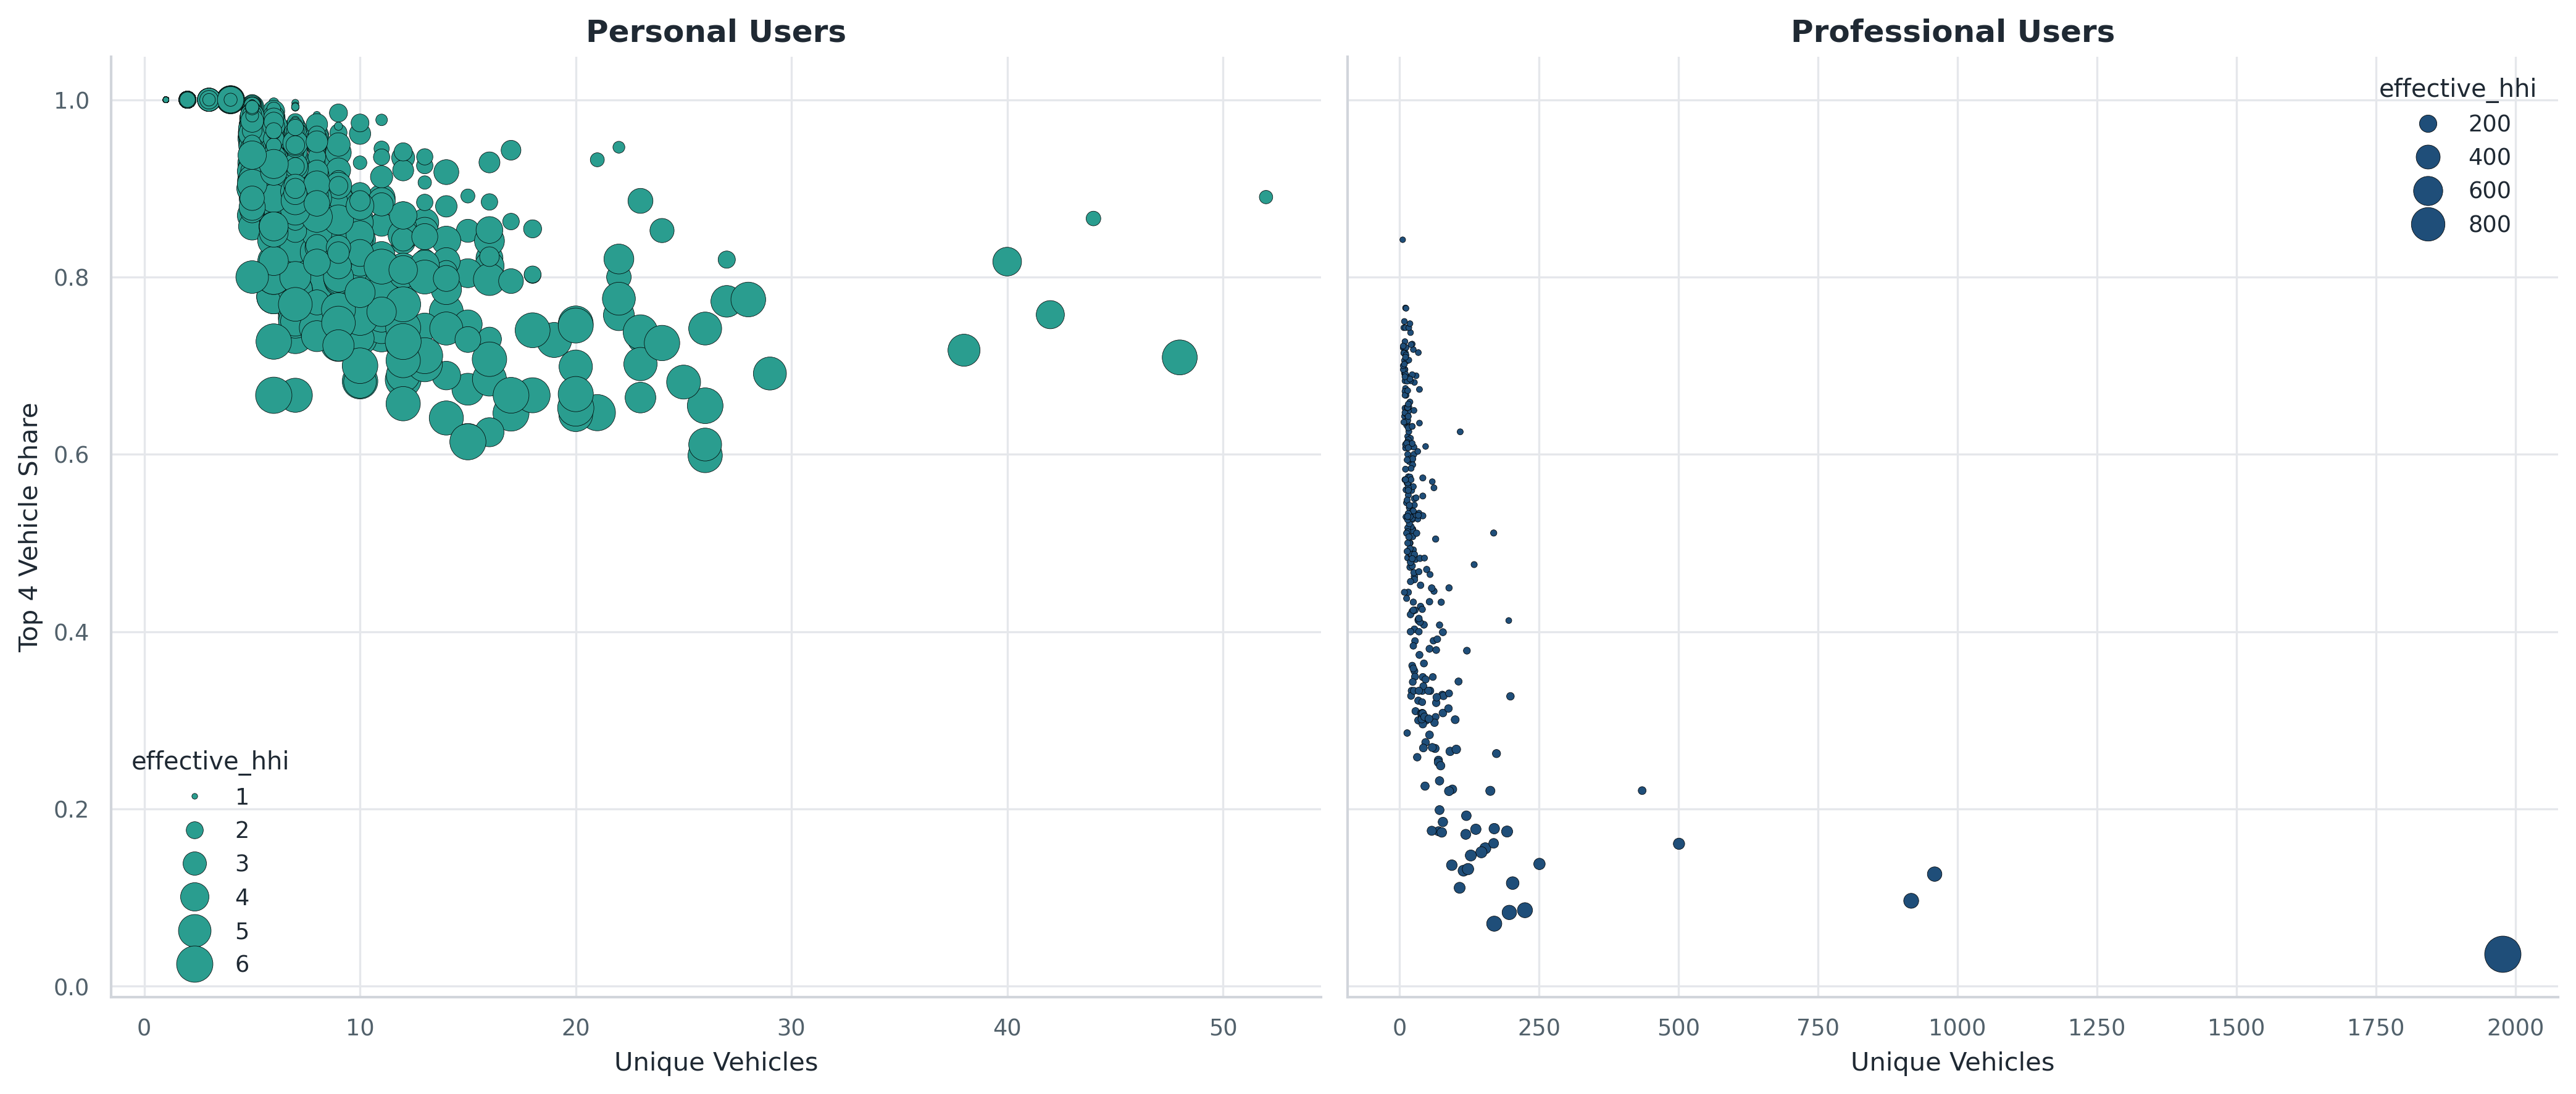

In [ ]:
fig1, ax1 = plot.subplots(nrows=1, ncols=2, sharey=True)

# Personal
percentage_car_share_personal = (
    df_1000_personal
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

sns.set_theme(**style.SEABORN_THEME)

hhi_personal = percentage_car_share_personal.pow(2).groupby(level=0).sum()
effective_hhi_personal = 1 / hhi_personal
n_personal = percentage_car_share_personal.groupby(level=0).size()
top4_share_personal = (
    percentage_car_share_personal
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

combined_personal = pd.DataFrame({
    "n": n_personal,
    "top4_share": top4_share_personal,
    "effective_hhi": effective_hhi_personal
}).dropna()

sns.scatterplot(
    x=combined_personal["n"],
    y=combined_personal["top4_share"],
    size=combined_personal["effective_hhi"],
    ax=ax1[0], color=style.PALETTE["Personal"], edgecolor="black",
    sizes=(5, 200), legend=True
)
ax1[0].set_ylabel("Top 4 Vehicle Share")
ax1[0].set_xlabel("Unique Vehicles")
ax1[0].set_title("Personal Users")

# ax1[0].set_ylim(0, 1)

# Professional
percentage_car_share_professional = (
    df_1000_professional
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_professional = percentage_car_share_professional.pow(2).groupby(level=0).sum()
effective_hhi_professional = 1 / hhi_professional
n_professional = percentage_car_share_professional.groupby(level=0).size()
top4_share_professional = (
    percentage_car_share_professional
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

combined_professional = pd.DataFrame({
    "n": n_professional,
    "top4_share": top4_share_professional,
    "effective_hhi": effective_hhi_professional
}).dropna()

sns.scatterplot(
    x=combined_professional["n"],
    y=combined_professional["top4_share"],
    size=combined_professional["effective_hhi"],
    ax=ax1[1], color=style.PALETTE["Professional"], edgecolor="black",
    sizes=(5, 200), legend=True
)
ax1[1].set_ylabel("Top 4 Vehicle Share")
ax1[1].set_xlabel("Unique Vehicles")
ax1[1].set_title("Professional Users")


fig1.set_tight_layout(tight=True)
fig1.set_size_inches((14, 6))



# Analysing Usage Patterns (frequency of usage + inactivity distribution)

In [ ]:
activity_df_1000.isnull().sum()

user_id              0
vehicle_id       13117
activity_date        0
app                  0
activity_type        0
dtype: int64

Personal Users:
 count    79167.000000
mean        18.043424
std         49.777658
min          0.083333
25%          0.833333
50%          3.083333
75%         13.541667
90%         44.166667
95%         83.833333
99%        230.764167
max       2142.875000
Name: activity_date, dtype: float64

Professional Users:
 count    28105.000000
mean         8.377038
std         26.125986
min          0.083333
25%          0.750000
50%          2.000000
75%          6.666667
90%         18.208333
95%         33.875000
99%        102.681667
max       1012.250000
Name: activity_date, dtype: float64


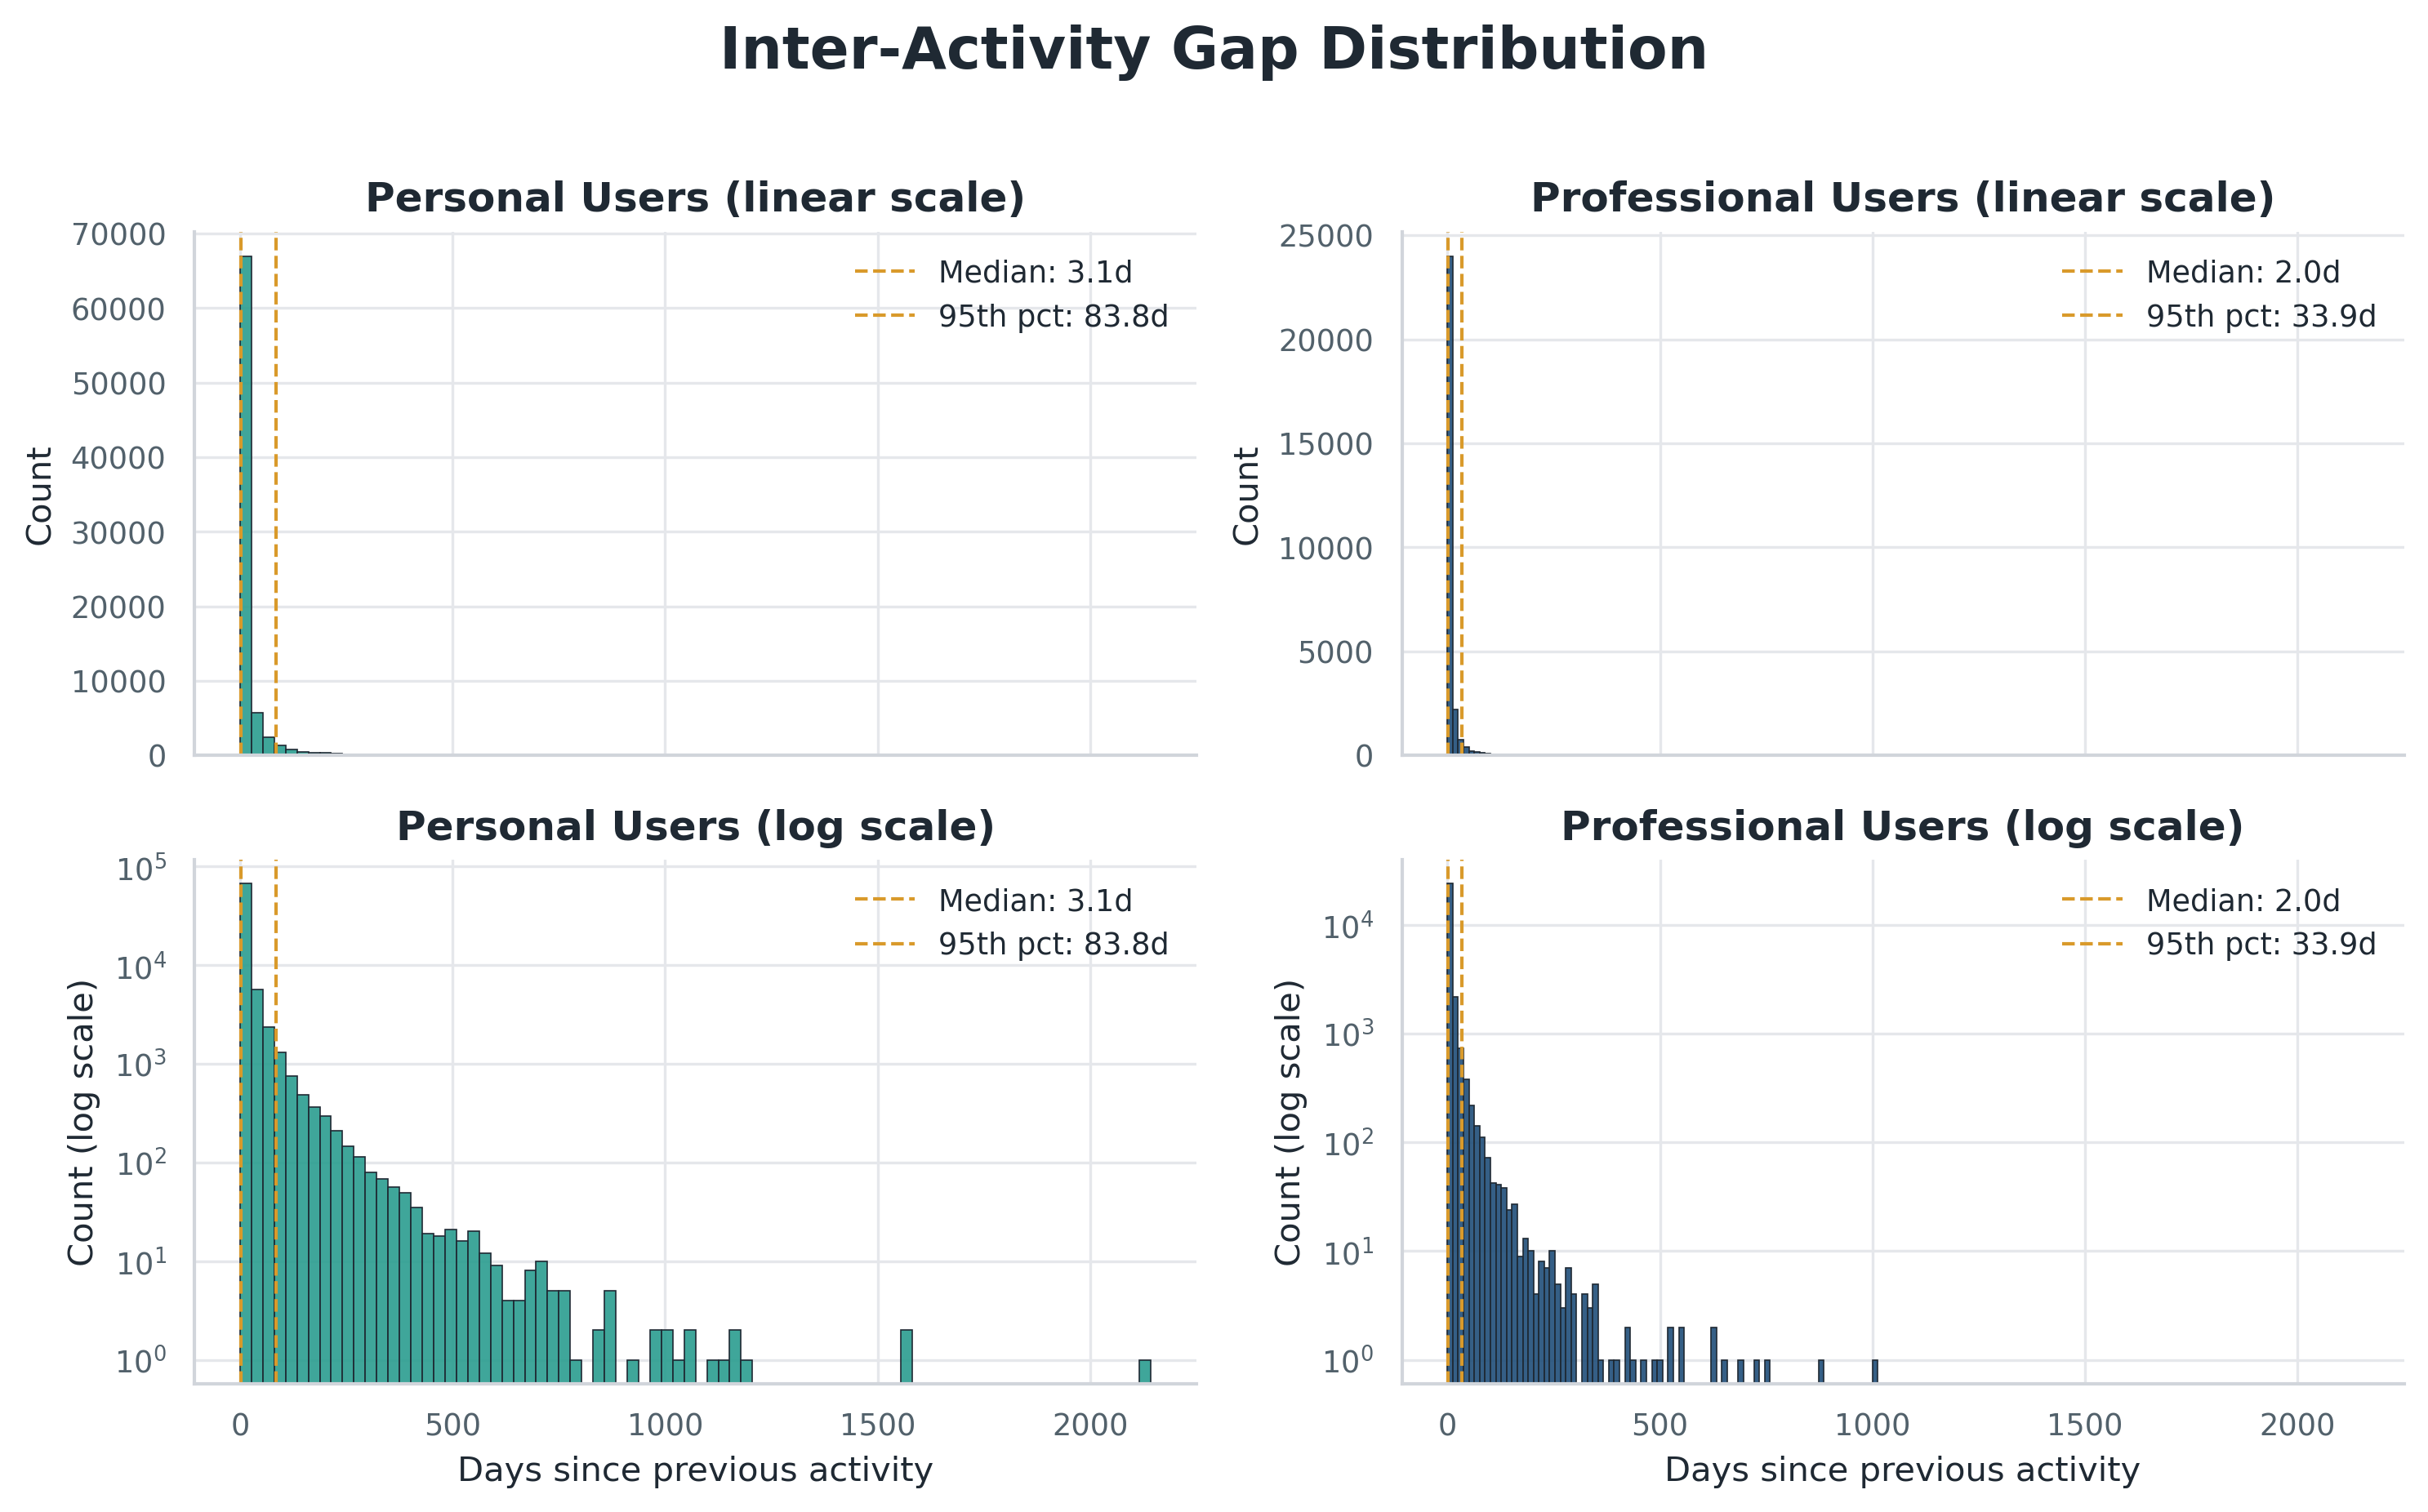

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Apply thesis style
sns.set_theme(**style.SEABORN_THEME)

PERSONAL_COLOR = style.PALETTE["Personal"]
PROFESSIONAL_COLOR = style.PALETTE["Professional"]
ACCENT_COLOR = style.COLORS["accent"]
EDGE_COLOR = style.COLORS["text"]
BACKGROUND = style.COLORS["background"]


def calculate_inter_activity_gap_days(df):
    """
    Calculate days since previous activity per user.
    Removes gaps <= 1 hour and trims values above the 99th percentile.
    """
    df = df.copy()

    df["activity_date"] = pd.to_datetime(df["activity_date"])
    df = df.sort_values(by=["user_id", "activity_date"])

    time_diff = (
        df["activity_date"]
        - df.groupby("user_id")["activity_date"].shift(1)
    )

    time_diff_hours = time_diff.dt.total_seconds().div(3600).round()
    time_diff_hours = time_diff_hours[time_diff_hours > 1]


    return time_diff_hours / 24


# Calculate inter-activity gaps
time_diff_personal = calculate_inter_activity_gap_days(df_1000_personal)
time_diff_professional = calculate_inter_activity_gap_days(df_1000_professional)


# Plot setup
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    sharex=True,
    figsize=(10, 6)
)

fig.patch.set_facecolor(BACKGROUND)

plot_data = [
    {
        "data": time_diff_personal,
        "color": PERSONAL_COLOR,
        "title": "Personal Users"
    },
    {
        "data": time_diff_professional,
        "color": PROFESSIONAL_COLOR,
        "title": "Professional Users"
    }
]


for col, group in enumerate(plot_data):
    data = group["data"]
    color = group["color"]
    title = group["title"]

    for row, use_log_scale in enumerate([False, True]):
        ax = axes[row, col]
        ax.set_facecolor(BACKGROUND)

        sns.histplot(
            data=data,
            bins=80,
            color=color,
            edgecolor=EDGE_COLOR,
            linewidth=0.4,
            alpha=0.9,
            ax=ax
        )

        if use_log_scale:
            ax.set_yscale("log")
            ax.set_ylabel("Count (log scale)")
            scale_label = "log scale"
        else:
            ax.set_ylabel("Count")
            scale_label = "linear scale"

        ax.set_xlabel("Days since previous activity")
        ax.set_title(f"{title} ({scale_label})")

        # Median and 95th percentile reference lines
        for percentile, label in [(0.5, "Median"), (0.95, "95th pct")]:
            value = data.quantile(percentile)

            ax.axvline(
                value,
                color=ACCENT_COLOR,
                linestyle="--",
                linewidth=1,
                label=f"{label}: {value:.1f}d"
            )

        ax.legend()
        sns.despine(ax=ax)


fig.suptitle(
    "Inter-Activity Gap Distribution",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.tight_layout()


print(
    "Personal Users:\n",
    time_diff_personal.describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

print()

print(
    "Professional Users:\n",
    time_diff_professional.describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

In [ ]:
import polars as pl
from datetime import timedelta
from src.constants.columns import (
    USER_ID_COL, ACTIVITY_DATE_COL, CHURN_ADJUSTED_DATE_COL,
    CHURN_TRIGGERED_COL, VEHICLE_ID_COL, VEHICLE_MAKE_COL,
    VEHICLE_MODEL_COL, VEHICLE_START_YEAR_COL, VEHICLE_END_YEAR_COL,
    VEHICLE_MILEAGE_COL, APP_COL, ACTIVITY_TYPE_COL,
    STILL_IN_PRODUCTION_COL, INTERVAL_START_COL,
    YEAR_BIN_LOWER, YEAR_BIN_UPPER, YEAR_BIN_UPPER_REPLACEMENT
)

In [ ]:
df = pl.read_csv(Path(r"C:\Users\Tomas\Desktop\Thesis Stuff\Survival_Analysis_Thesis\Coding\Data\interim\personal_users_dataset.csv"))



FileNotFoundError: The system cannot find the file specified. (os error 2): ...top\Thesis Stuff\Survival_Analysis_Thesis\Coding\Data\interim\personal_users_dataset.csv (set POLARS_VERBOSE=1 to see full path)

In [ ]:
df = df.with_columns(pl.col("activity_date").str.to_datetime(time_unit="us",time_zone="UTC").dt.date())

In [ ]:
df = df.sort(["user_id","activity_date"])

In [ ]:
interval=1

In [ ]:
churn_adjusted_date_col_name = ACTIVITY_DATE_COL

user_min_max_dates = df.group_by(USER_ID_COL).agg(
    pl.col(churn_adjusted_date_col_name).min().alias("start_date"),
    pl.col(churn_adjusted_date_col_name).max().alias("end_date")
)

intervals = user_min_max_dates.with_columns(
    pl.date_ranges(
        start=pl.col("start_date"),
        end=pl.col("end_date"),
        interval=timedelta(days=interval)
    ).alias(INTERVAL_START_COL)
).explode(INTERVAL_START_COL).select([USER_ID_COL, INTERVAL_START_COL])

df_with_intervals = df.join_asof(
    intervals,
    left_on=churn_adjusted_date_col_name,
    right_on=INTERVAL_START_COL,
    by=USER_ID_COL,
    strategy="backward"
)

df_with_intervals = (
    df_with_intervals
    .unique(subset=[USER_ID_COL, ACTIVITY_DATE_COL], keep="first")
    .sort([USER_ID_COL, ACTIVITY_DATE_COL])
    .with_columns(
        (pl.col(ACTIVITY_DATE_COL) - pl.col(ACTIVITY_DATE_COL).shift(1).over("user_id") - timedelta(1)).dt.total_days().alias("gap"))
    
)

df_with_intervals = (
    df_with_intervals
    .unique(subset=[USER_ID_COL, ACTIVITY_DATE_COL], keep="first")
    .sort([USER_ID_COL, ACTIVITY_DATE_COL])
    .with_columns(
        (pl.col(ACTIVITY_DATE_COL).shift(1).over("user_id").alias("previous"))))

df_with_intervals.sort([USER_ID_COL, ACTIVITY_DATE_COL])

df_filtered = df_with_intervals.filter(pl.col("gap").is_not_null())

df_filtered.select(pl.col("gap")).describe()

C:\Users\Tomas\AppData\Local\Temp\ipykernel_12412\2036793278.py:16: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(


statistic,gap
str,f64
"""count""",51107.0
"""null_count""",0.0
"""mean""",12.854834
"""std""",23.359457
"""min""",0.0
"""25%""",0.0
"""50%""",4.0
"""75%""",13.0
"""max""",159.0


In [ ]:
df = pl.read_csv(Path(r"C:\Users\Tomas\Desktop\Thesis Stuff\Survival_Analysis_Thesis\Coding\Data\interim\personal_users_dataset.csv"))
df = df.with_columns(
            pl.col(CHURN_ADJUSTED_DATE_COL)
            .str.to_datetime(time_unit="us", time_zone="UTC")
            .dt.date()
            .alias(CHURN_ADJUSTED_DATE_COL)
        ).sort(by=[USER_ID_COL, ACTIVITY_DATE_COL])

df = df.with_columns(
    pl.col(ACTIVITY_DATE_COL)
    .str.to_datetime(time_unit="us", time_zone="UTC")
    .dt.date()
    .alias(ACTIVITY_DATE_COL)
).sort(by=[USER_ID_COL, ACTIVITY_DATE_COL])

In [ ]:
user_min_max_dates = df.group_by(USER_ID_COL).agg(
    pl.col(churn_adjusted_date_col_name).min().alias("start_date"),
    pl.col(churn_adjusted_date_col_name).max().alias("end_date")
)


intervals = user_min_max_dates.with_columns(
    pl.date_ranges(
        start=pl.col("start_date"),
        end=pl.col("end_date"),
        interval=timedelta(days=28)
    ).alias(INTERVAL_START_COL)
).explode(INTERVAL_START_COL).select([USER_ID_COL, INTERVAL_START_COL])

df_with_intervals = df.join_asof(
    intervals,
    left_on=churn_adjusted_date_col_name,
    right_on=INTERVAL_START_COL,
    by=USER_ID_COL,
    strategy="backward"
)

df_with_intervals = intervals.join(
            df_with_intervals,
            on=[USER_ID_COL, INTERVAL_START_COL],
            how="left"
        )

# df_with_intervals = df_with_intervals.with_columns([
#     pl.col(CHURN_TRIGGERED_COL).fill_null(False),
#     pl.col(VEHICLE_ID_COL).fill_null("unknown"),
#     pl.col(VEHICLE_MAKE_COL).fill_null("unknown"),
#     pl.col(VEHICLE_MODEL_COL).fill_null("unknown"),
#     pl.col(VEHICLE_START_YEAR_COL).fill_null(0),
#     pl.col(VEHICLE_END_YEAR_COL).fill_null(0),
#     pl.col(VEHICLE_MILEAGE_COL).fill_null("unknown"),
#     pl.col(ACTIVITY_DATE_COL).fill_null(pl.lit(None).cast(pl.Date)),
#     pl.col(APP_COL).fill_null("unknown"),
#     pl.col(ACTIVITY_TYPE_COL).fill_null("none"),
#     pl.col(STILL_IN_PRODUCTION_COL).fill_null(False),
#     pl.col(churn_adjusted_date_col_name).fill_null(pl.lit(None).cast(pl.Date)),
# ])
df_actions = df_with_intervals.group_by([USER_ID_COL, INTERVAL_START_COL]).agg(
    pl.col(ACTIVITY_TYPE_COL).is_not_null().sum().alias("total_actions")).sort([USER_ID_COL, INTERVAL_START_COL])

C:\Users\Tomas\AppData\Local\Temp\ipykernel_12412\4167399679.py:15: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(


In [ ]:
df_actions

user_id,interval_start,total_actions
str,date,u32
"""0036f2d9601ad1ea7d95cb2f86a6db…",2023-08-06,5
"""0036f2d9601ad1ea7d95cb2f86a6db…",2023-09-03,3
"""0036f2d9601ad1ea7d95cb2f86a6db…",2023-10-01,1
"""0036f2d9601ad1ea7d95cb2f86a6db…",2023-10-29,0
"""0036f2d9601ad1ea7d95cb2f86a6db…",2023-11-26,0
…,…,…
"""ffe5c316bd2dbd4f5b052c37453f5f…",2025-12-28,0
"""ffe5c316bd2dbd4f5b052c37453f5f…",2026-01-25,1
"""ffe5c316bd2dbd4f5b052c37453f5f…",2026-02-22,0


In [ ]:
df_actions.select((pl.col("total_actions") == 0).sum() / pl.len())

total_actions
f64
0.313952


In [ ]:
user_min_max_dates = df.group_by(USER_ID_COL).agg(
    pl.col(churn_adjusted_date_col_name).min().alias("start_date"),
    pl.col(churn_adjusted_date_col_name).max().alias("end_date")
)


intervals = user_min_max_dates.with_columns(
    pl.date_ranges(
        start=pl.col("start_date"),
        end=pl.col("end_date"),
        interval=timedelta(days=28)
    ).alias(INTERVAL_START_COL)
).explode(INTERVAL_START_COL).select([USER_ID_COL, INTERVAL_START_COL])

df_with_intervals = df.join_asof(
    intervals,
    left_on=churn_adjusted_date_col_name,
    right_on=INTERVAL_START_COL,
    by=USER_ID_COL,
    strategy="backward"
)

df_with_intervals = intervals.join(
            df_with_intervals,
            on=[USER_ID_COL, INTERVAL_START_COL],
            how="left"
        )

# df_with_intervals = df_with_intervals.with_columns([
#     pl.col(CHURN_TRIGGERED_COL).fill_null(False),
#     pl.col(VEHICLE_ID_COL).fill_null("unknown"),
#     pl.col(VEHICLE_MAKE_COL).fill_null("unknown"),
#     pl.col(VEHICLE_MODEL_COL).fill_null("unknown"),
#     pl.col(VEHICLE_START_YEAR_COL).fill_null(0),
#     pl.col(VEHICLE_END_YEAR_COL).fill_null(0),
#     pl.col(VEHICLE_MILEAGE_COL).fill_null("unknown"),
#     pl.col(ACTIVITY_DATE_COL).fill_null(pl.lit(None).cast(pl.Date)),
#     pl.col(APP_COL).fill_null("unknown"),
#     pl.col(ACTIVITY_TYPE_COL).fill_null("none"),
#     pl.col(STILL_IN_PRODUCTION_COL).fill_null(False),
#     pl.col(churn_adjusted_date_col_name).fill_null(pl.lit(None).cast(pl.Date)),
# ])
df_actions = df_with_intervals.group_by([USER_ID_COL, INTERVAL_START_COL]).agg(
    pl.col(ACTIVITY_TYPE_COL).is_not_null().sum().alias("total_actions")).sort([USER_ID_COL, INTERVAL_START_COL])

df_with_intervals.group_by(USER_ID_COL).agg(pl.col(INTERVAL_START_COL).n_unique().alias("n_intervals")).select(pl.col("n_intervals").mean().alias("mean_interval"))

C:\Users\Tomas\AppData\Local\Temp\ipykernel_12412\1481773890.py:15: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(


mean_interval
f64
11.279001


In [ ]:
df_actions.select((pl.col("total_actions") == 0).sum() / pl.len())

total_actions
f64
0.313952


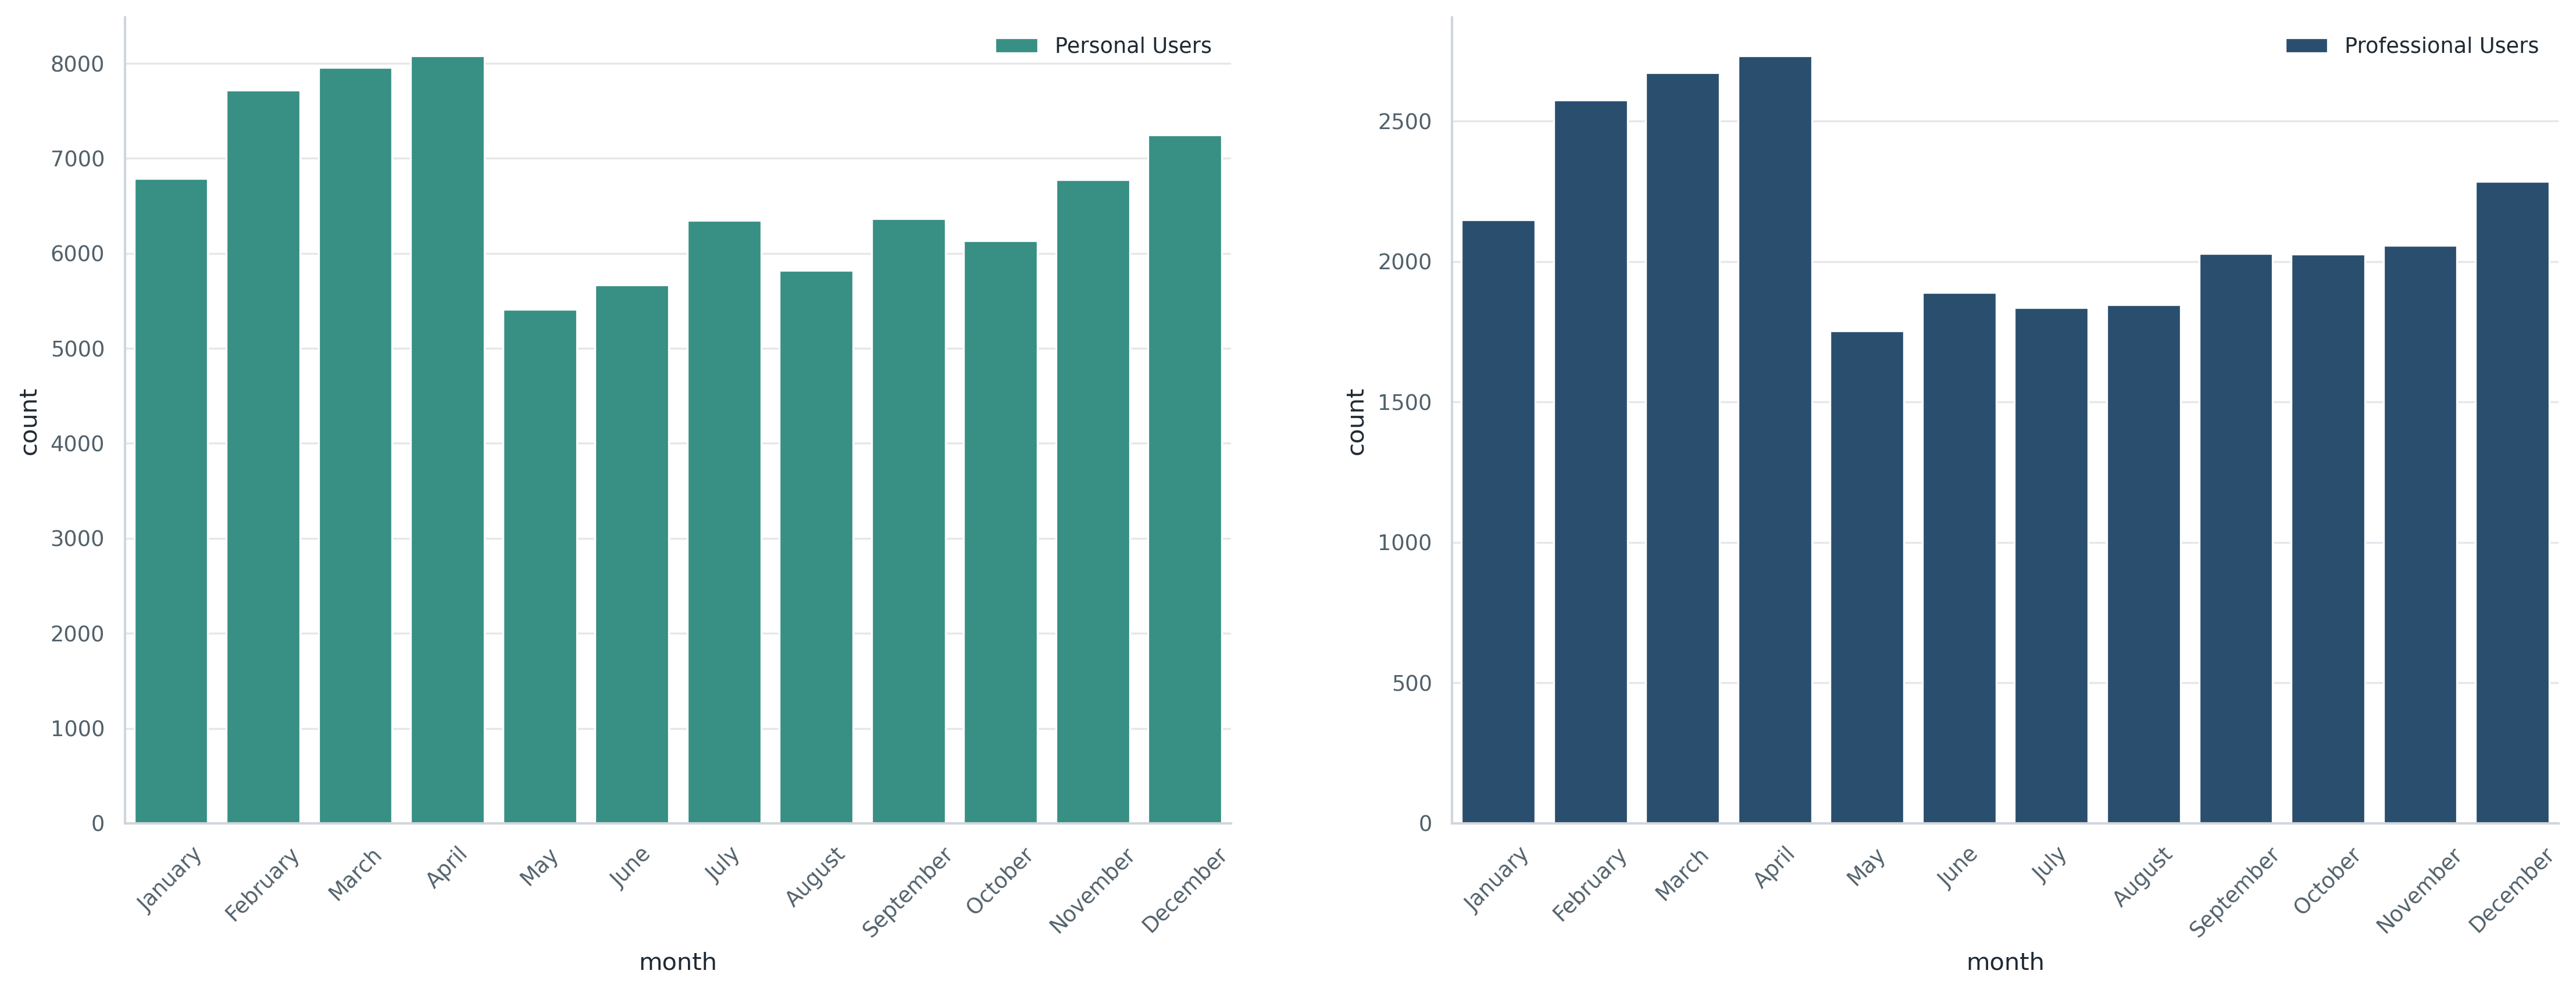

In [ ]:
# df_1000_personal["activity_date"].dt.month_name()
fig_usage, ax_usage = plot.subplots(nrows=1, ncols=2)
df = df_1000_personal.copy()

df["activity_date"] = pd.to_datetime(df["activity_date"])
df = df.sort_values(by=["user_id", "activity_date"])

time_diff = (
      df["activity_date"]
      - df.groupby("user_id")["activity_date"].shift(1)
)

time_diff_hours = time_diff.dt.total_seconds().div(3600).round()
filtered_time  = time_diff_hours[time_diff_hours > 1]

df = df_1000_professional.copy()

df["activity_date"] = pd.to_datetime(df["activity_date"])
df = df.sort_values(by=["user_id", "activity_date"])

time_diff = (
      df["activity_date"]
      - df.groupby("user_id")["activity_date"].shift(1)
)

time_diff_hours = time_diff.dt.total_seconds().div(3600).round()
filtered_time_p = time_diff_hours[time_diff_hours > 1]




plot_df_usage   = df_1000_personal.loc[filtered_time.index, ["activity_date"]].copy()
plot_df_usage_p = df_1000_professional.loc[filtered_time_p.index, ["activity_date"]].copy()

plot_df_usage["activity_date"] = pd.to_datetime(plot_df_usage["activity_date"])
plot_df_usage_p["activity_date"] = pd.to_datetime(plot_df_usage_p["activity_date"])

plot_df_usage["month"]   = plot_df_usage["activity_date"].dt.month_name()
plot_df_usage_p["month"] = plot_df_usage_p["activity_date"].dt.month_name()


sns.set_theme(**style.SEABORN_THEME)
sns.countplot(data=plot_df_usage,
              x="month",
              ax=ax_usage[0],
              order=[
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"],
        color=style.PALETTE["Personal"],
        label="Personal Users")
sns.countplot(data=plot_df_usage_p,
              x="month",
              ax=ax_usage[1],
              order=[
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"],
        color=style.PALETTE["Professional"],
        label="Professional Users")

fig_usage.set_size_inches(w=18,h=6)
fig.tight_layout()


for _ax in ax_usage:
    _ax: Axes
    _ax.tick_params(axis='x',labelrotation=45)

In [ ]:
df_1000_personal.sort_values(["user_id","activity_date"])

df_1000_personal["activity_date"].dt.isocalendar()

,year,week,day
0,2025,40,7
3,2026,11,2
4,2025,21,5
5,2025,40,6
6,2024,43,7
...,...,...,...
567947,2026,17,2
567948,2026,11,6
567949,2026,10,7
567951,2026,11,6


### NOTE:

The below code is not a full representation of what's going on (it's accurate enoguh though). The reasoning is that when applying data cleaner class get_cleaned_data() function it sets a cutoff date max.date - set_threshold. The cutoff filtering happened way before the code written below and therefore could include users that would not have yet had the time to experience hte event.

In [ ]:


churn_threshold_personal = [70,160,180]

for threshold in churn_threshold_personal:

    n_churners = data_cleaner_1000.filter_after_inactivity(df_1000_personal,threshold_value=threshold)["churn_triggered"].sum()
    print(n_churners)



2087
1365
1216


<Axes: >

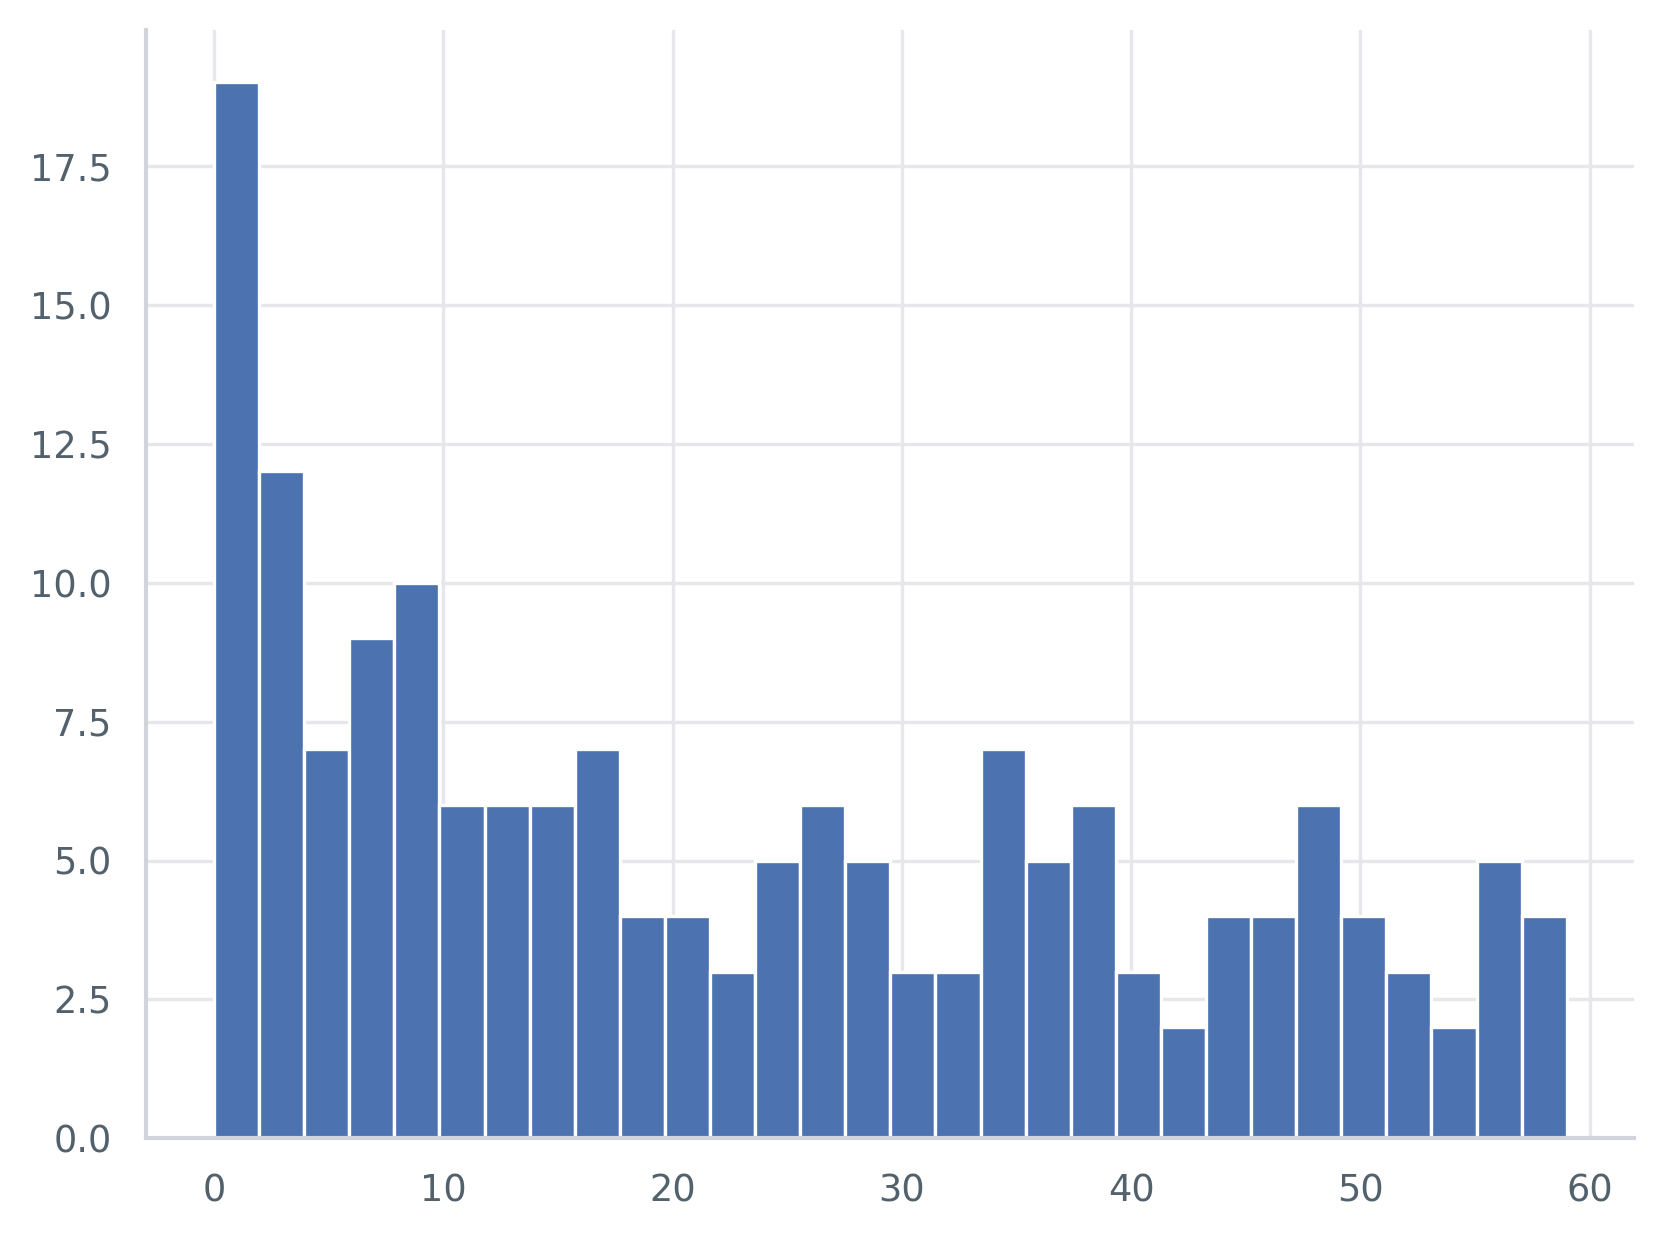

In [ ]:
observation_windows = df_1000_personal.groupby("user_id")["activity_date"].max() - df_1000_personal.groupby("user_id")["activity_date"].min()

short = observation_windows.dt.days
short[short < 60].hist(bins=30)


In [ ]:
churn_threshold_professional = [27,60, 90]

for threshold in churn_threshold_professional:

    n_churners = data_cleaner_1000.filter_after_inactivity(df_1000_professional,threshold_value=threshold)["churn_triggered"].sum()
    print(n_churners)



240
196
152


In [ ]:

vehicle_ids_present = pd.Series(activity_df_1000["vehicle_id"].unique()).isin(vehicle_df_1000["vehicle_id"].unique()).sum()

percentage = (int(activity_df_1000["vehicle_id"].nunique()) - int(vehicle_ids_present)) / int(activity_df_1000["vehicle_id"].nunique()) 


print(f"Percentage of 'vehicle_id' metadata missing {percentage*100:.2f}%")




Percentage of 'vehicle_id' metadata missing 0.00%


In [ ]:
vehicle_df_1000["vehicle_make"].unique()


vehicle_df_1000["vehicle_make"].value_counts()

vehicle_make
Volkswagen       13992
Audi              9442
Skoda             3467
Seat              2026
BMW               1003
Porsche            250
Mercedes-Benz      177
Ford               128
Toyota             113
MINI                56
MAN                 28
Lexus               23
Lamborghini         22
Bentley             17
BMW Moto            11
Toyota GR            2
Name: count, dtype: int64

In [ ]:
group_by_user_vehicle = vehicle_df_1000.groupby([USER_ID_COL, VEHICLE_ID_COL])[VEHICLE_ID_COL]
 
mm = group_by_user_vehicle.count().gt(1).groupby(level=0).any()

mm.sum()

np.int64(1)

In [ ]:
import polars as pl
df_personal_pl  = pl.read_csv(r"C:\Users\Tomas\Desktop\Thesis Stuff\Survival_Analysis_Thesis\Coding\Data\interim\personal_users_dataset.csv")

In [ ]:
df_personal_pl.select(pl.col("user_id")).n_unique()


2362

In [ ]:
df_1000_personal["user_id"].nunique()

2390

In [ ]:
(vehicle_df_1000.vehicle_end_year.isna().mean())

np.float64(0.07523490587508534)

In [ ]:
print(merged_raw_1000.groupby(USER_ID_COL)[VEHICLE_ID_COL].nunique().quantile(0.95))

28.0
